In [1]:
# import package
from datetime import date,timedelta
from urllib.request import urlopen
from dateutil import rrule
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
import pandas as pd
import numpy as np
import json
import time
import mplfinance
import mpl_finance
import requests
from io import StringIO
from dateutil.relativedelta import relativedelta

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

/opt/anaconda3/lib/python3.7/site-packages/mpl_finance.py:22: DeprecationWarning: 



    Please use `mplfinance` instead (no hyphen, no underscore).

    To install: `pip install --upgrade mplfinance` 

   For more information, see: https://pypi.org/project/mplfinance/


  category=DeprecationWarning)


# 檔案存取相關

In [2]:
traget_floder=r"Data/"

def get_file_path(file_type,stock_number,date):
    date_=date.strftime("%Y-%m-%d")
    filename=file_type+'_'+str(stock_number)+'_'+date_+".json"
    path=traget_floder+filename
    return path

def Reading_from_json_file(file_type,stock_number,date):
    file_path=get_file_path(file_type,stock_number,date)
    with open(file_path, 'r') as openfile:
        json_object = json.load(openfile)
    return json_object

def writing_to_json(file_type,stock_number,date,dictionary):
    file_path=get_file_path(file_type,stock_number,date)
    with open(file_path, "w") as outfile:
        json.dump(dictionary, outfile)

# 公用ＦＵＮＣ

In [3]:
# 確認是否已被抓取過
def check_data_exist(file_type,stock_number,date):
    print(file_type,stock_number,date)
    stock_number_=str(stock_number)
    date_=date.strftime("%Y-%m-%d")
    
    check=His_Stock[(His_Stock['type']==file_type)]
    check=check[(check['stock_number']==stock_number_)]
    check=check[(check['date']==date_)]
    
    if len(check.index)==0 :
        return False
    return True

def log_(His_Stock,file_type,stock_number,date,status,data):
    df2=pd.DataFrame({
        "type":file_type,
        "stock_number":str(stock_number),
        "date":date.strftime("%Y-%m-%d"),
        "status":status,
    },index=[0])    
    
    writing_to_json(file_type,stock_number,date,data)
    df_log=His_Stock.append(df2, ignore_index=True)
    return df_log

# 爬取每月股價

In [4]:

# 爬取每月股價的目標網站並包裝成函式
def craw_one_month(His_Stock,file_type,stock_number,date):
    url = (
        "http://www.twse.com.tw/exchangeReport/STOCK_DAY?response=json&date="+
        date.strftime('%Y%m%d')+
        "&stockNo="+
        str(stock_number)
    )
    data = json.loads(urlopen(url).read())

    # For log
    status=data['stat']
    His_Stock=log_(His_Stock,file_type,stock_number,date,status,data)

    if status=="OK":
        return pd.DataFrame(data['data'],columns=data['fields']),His_Stock

    return pd.DataFrame(),His_Stock



#根據使用者輸入的日期，以月為單位，重複呼叫爬取月股價的函式
#https://ithelp.ithome.com.tw/articles/10213955
def craw_stock(His_Stock,stock_number, start_month,end_time=datetime.datetime.now().strftime("%Y-%m-%d") ):
    file_type="Stock_His"
    b_month = date(*[int(x) for x in start_month.split('-')])
    e_month = date(*[int(x) for x in end_time.split('-')])
    result = pd.DataFrame()
    
    for dt in rrule.rrule(rrule.MONTHLY, dtstart=b_month, until=e_month):

        if check_data_exist(file_type,stock_number,dt):
            #內部存取
            print(file_type,stock_number,dt.strftime("%Y-%m-%d"),"===>內部存取")
            data=Reading_from_json_file(file_type,stock_number,dt)
            get_df_stock_data=pd.DataFrame(data['data'],columns=data['fields'])
        else:
            #外部抓取
            print(file_type,stock_number,dt.strftime("%Y-%m-%d"),"===>外部抓取")
            get_df_stock_data,His_Stock=craw_one_month(His_Stock,file_type,stock_number,dt)
            if(dt.strftime("%Y-%m-%d")==e_month):
                time.sleep(6) #如果在 6 秒內連續擷取兩次，那 IP 就會被鎖住，要一個小時後才能繼續擷取

        result = pd.concat([result,get_df_stock_data],ignore_index=True)   

    return result,His_Stock


In [5]:

His_Stock = pd.read_csv('His_Stock.csv')
His_Stock["stock_number"]=His_Stock['stock_number'].astype('str')
RowData_df_craw_stock,His_Stock = craw_stock(His_Stock,'2330',"2021-06-01","2021-06-01")
RowData_df_craw_stock.head(10)

Stock_His 2330 2021-06-01 00:00:00
Stock_His 2330 2021-06-01 ===>內部存取


,日期,成交股數,成交金額,開盤價,最高價,最低價,收盤價,漲跌價差,成交筆數
0,110/06/01,"18,405,285","10,985,893,229",598.00,599.00,595.00,598.00,+1.00,"20,318"
1,110/06/02,"22,416,789","13,362,065,937",600.00,600.00,593.00,595.00,-3.00,"25,170"
2,110/06/03,"31,703,679","18,939,839,664",600.00,600.00,596.00,596.00,+1.00,"20,749"
3,110/06/04,"16,072,580","9,521,252,157",591.00,595.00,590.00,595.00,-1.00,"19,112"
4,110/06/07,"17,729,179","10,471,176,330",594.00,595.00,583.00,592.00,-3.00,"25,364"
5,110/06/08,"14,083,552","8,312,653,665",590.00,595.00,588.00,589.00,-3.00,"14,051"
6,110/06/09,"21,575,159","12,618,113,390",586.00,588.00,583.00,586.00,-3.00,"36,405"
7,110/06/10,"29,741,770","17,696,413,894",591.00,599.00,587.00,599.00,+13.00,"30,487"
8,110/06/11,"24,940,705","15,011,140,567",602.00,603.00,600.00,602.00,+3.00,"25,271"
9,110/06/15,"30,245,897","18,415,370,774",607.00,609.00,606.00,609.00,+7.00,"33,515"


In [6]:
def DataCleaning(input_RowData):    
    
    # 如果不使用copy 會導致變動到原本資料  https://www.796t.com/article.php?id=22560
    df=input_RowData.copy()
    #處理資料格式 
    df['Year']=df['日期'].str.split('/', 1).str[0]
    df['Date']=df['日期'].str.split('/', 1).str[1]
    df['Year']=df.apply(lambda x:int( x['Year'])+1911 , axis=1)
    df['日期']=df.apply(lambda x: str(x['Year'])+'/'+ x['Date'], axis=1)
    df.set_index("日期", inplace=True)
    df['成交股數']=df.apply(lambda x: x['成交股數'].replace(",",""), axis=1)
    df['成交股數'] = df['成交股數'].astype(int)
    df['成交筆數']=df.apply(lambda x: x['成交筆數'].replace(",",""), axis=1)
    df['成交筆數'] = df['成交筆數'].astype(int)

    # 將爬取到的歷年股價資訊繪成圖表
    #df['收盤價']=df['收盤價'].astype(float)
    #df.loc[:]['收盤價'].plot(figsize=(18, 8))
    #plt.xlabel('month')
    #plt.ylabel('stock')
    #filter
    df = df[['開盤價','最高價','最低價','收盤價','成交筆數']]
    df.index.name = '日期'
    df.index = pd.to_datetime(df.index)
    df = df.astype(float)
    df_ohlcv = {'開盤價': 'first',
               '最高價': 'max',
               '最低價': 'min',
               '收盤價': 'last',
               '成交筆數': 'sum'}

    #df_final = df.resample('W-MON',closed='left', label='left').agg(df_ohlcv).copy()

    df_final = df.resample('D',closed='left', label='left').agg(df_ohlcv).copy()
    df_final.index = mdates.date2num(df_final.index)
    data_final = df_final.reset_index().values
    return  data_final,df_final

In [7]:
data_final,df_final=DataCleaning(RowData_df_craw_stock)

# Revenue

In [8]:

def craw_revenue_one_month_report(His_Stock,file_type,year,month):
    stock_number=0
    date=datetime.datetime.strptime(str(year)+"-"+str(month), '%Y-%m')

    print(date,"#外部撈取")
    # 外部撈取
    # 參數處理-西元轉民國
    if year > 1990:
        year -= 1911
    # 參數處理-url
    url = 'https://mops.twse.com.tw/nas/t21/sii/t21sc03_'+str(year)+'_'+str(month)+'_0.html'
    if year <= 98:
        url = 'https://mops.twse.com.tw/nas/t21/sii/t21sc03_'+str(year)+'_'+str(month)+'.html'

    # 偽瀏覽器
    headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_10_1) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/39.0.2171.95 Safari/537.36'}

    # 下載該年月的網站，並用pandas轉換成 dataframe
    r = requests.get(url, headers=headers)
    r.encoding = 'big5'

    dfs = pd.read_html(StringIO(r.text), encoding='big-5')

    df = pd.concat([df for df in dfs if df.shape[1] <= 11 and df.shape[1] > 5])

    if 'levels' in dir(df.columns):
        df.columns = df.columns.get_level_values(1)
    else:
        df = df[list(range(0,10))]
        column_index = df.index[(df[0] == '公司代號')][0]
        df.columns = df.iloc[column_index]

    df['當月營收'] = pd.to_numeric(df['當月營收'], 'coerce')
    df['月份']=str(year+1911)+'-'+str(month).zfill(2)+'-01'
    df = df[~df['當月營收'].isnull()]
    df = df[df['公司代號'] != '合計']


    # for log
    df_tojson=df.copy()
    df_tojson.reset_index(drop=True, inplace=True)
    data = df_tojson.to_json(orient="split", force_ascii=False) 
    status="OK"
    His_Stock=log_(His_Stock,file_type,stock_number,date,status,data)


    return df,His_Stock

#<!-------- end_time 預設取得現在時間減掉一個月

def craw_revenue(His_Stock,stock_number, start_month,end_time=(datetime.datetime.now() +relativedelta(months=-1)).strftime("%Y-%m-%d")   ):
    file_type="Revenue_His"
  
    b_month = date(*[int(x) for x in start_month.split('-')])
    
    # 因營收最多只能拿到上個月的資訊 如果輸入時間太大校正
    if end_time>(datetime.datetime.now() +relativedelta(months=-1)).strftime("%Y-%m-%d"):
        end_time = (datetime.datetime.now() +relativedelta(months=-1)).strftime("%Y-%m-%d")    
    e_month = date(*[int(x) for x in end_time.split('-')])
    result = pd.DataFrame()
    
    for dt in rrule.rrule(rrule.MONTHLY, dtstart=b_month, until=e_month):
        stock_number_=0
        Year,month= int(dt.strftime('%Y')),int(dt.strftime('%m'))
        dtdate=datetime.datetime.strptime(str(Year)+"-"+str(month), '%Y-%m')
        print(dtdate)
        if check_data_exist(file_type,stock_number_,dtdate):
            #內部讀取
            print(dtdate,"#內部讀取")
            data=Reading_from_json_file(file_type,stock_number_,dtdate)
            xxx=json.loads(data)
            revenue_data=pd.DataFrame(xxx['data'],columns=xxx['columns'])
           
        else:
            revenue_data,His_Stock=craw_revenue_one_month_report(His_Stock,file_type,Year,month)
            time.sleep(5);
        #print(revenue_data[revenue_data['公司代號']==stock_number])
        result = pd.concat([result,revenue_data],ignore_index=True)
    #return result ,His_Stock
    return result[result['公司代號']==stock_number],His_Stock


In [9]:
RowData_df_craw_revenue,His_Stock=craw_revenue(His_Stock,'2330',"2021-06-01","2021-07-01")

2021-06-01 00:00:00
Revenue_His 0 2021-06-01 00:00:00
2021-06-01 00:00:00 #內部讀取
2021-07-01 00:00:00
Revenue_His 0 2021-07-01 00:00:00
2021-07-01 00:00:00 #外部撈取


In [10]:
RowData_df_craw_revenue

,公司代號,公司名稱,備註,上月比較增減(%),上月營收,去年同月增減(%),去年當月營收,當月營收,前期比較增減(%),去年累計營收,當月累計營收,月份
278,2330,台積電,無。,32.13,112359668,22.82,120877785,148470660,18.22,621295550,734555352,2021-06-01


In [11]:
def RevenueDataCleaning(input_RowData):
    rowdata_revenue=input_RowData.copy()
    rowdata_revenue['revenue']=rowdata_revenue['當月營收']
    revenue_df = rowdata_revenue[['月份','revenue']]
    revenue_df.set_index("月份", inplace=True)
    revenue_df.index.name = 'date'
    revenue_df.index = pd.to_datetime(revenue_df.index)
    return revenue_df
df_Revenue=RevenueDataCleaning(RowData_df_craw_revenue)

In [12]:
#https://ycy-tai.medium.com/python-finance-利用python繪製股價走勢圖-building-stock-chart-with-python-3bcb6d55020d
def drew(data_final,df_final,revenue_df):
    fig,ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 5), sharex=True,
                             gridspec_kw={'height_ratios': [4, 1]})

    mpl_finance.candlestick_ohlc(ax[0], data_final, width=.5, alpha=1, colorup="red", colordown="green")
    ax[1].bar(df_final.index, df_final['成交筆數'], width=.5
              , color='#114f85')
    ax[0].set_ylabel('Price')

    locator = mdates.AutoDateLocator()
    ax[0].xaxis.set_major_locator(locator)
    ax[0].xaxis.set_major_formatter(mdates.AutoDateFormatter(locator))
    #############
    ax2=ax[0].twinx()
    ax2.plot(revenue_df.revenue.astype(float),label='Revenue',linewidth=1, 
             alpha=0.7,color='#374552', marker='o',
             markerfacecolor='#374552',markersize=6)

    ax2.set_ylabel('Revenue')
    
  

Stock_His 2330 2021-01-01 00:00:00
Stock_His 2330 2021-01-01 ===>內部存取
Stock_His 2330 2021-02-01 00:00:00
Stock_His 2330 2021-02-01 ===>內部存取
Stock_His 2330 2021-03-01 00:00:00
Stock_His 2330 2021-03-01 ===>內部存取
Stock_His 2330 2021-04-01 00:00:00
Stock_His 2330 2021-04-01 ===>內部存取
Stock_His 2330 2021-05-01 00:00:00
Stock_His 2330 2021-05-01 ===>內部存取
Stock_His 2330 2021-06-01 00:00:00
Stock_His 2330 2021-06-01 ===>內部存取
2021-01-01 00:00:00
Revenue_His 0 2021-01-01 00:00:00
2021-01-01 00:00:00 #內部讀取
2021-02-01 00:00:00
Revenue_His 0 2021-02-01 00:00:00
2021-02-01 00:00:00 #內部讀取
2021-03-01 00:00:00
Revenue_His 0 2021-03-01 00:00:00
2021-03-01 00:00:00 #內部讀取
2021-04-01 00:00:00
Revenue_His 0 2021-04-01 00:00:00
2021-04-01 00:00:00 #內部讀取
2021-05-01 00:00:00
Revenue_His 0 2021-05-01 00:00:00
2021-05-01 00:00:00 #內部讀取
2021-06-01 00:00:00
Revenue_His 0 2021-06-01 00:00:00
2021-06-01 00:00:00 #內部讀取


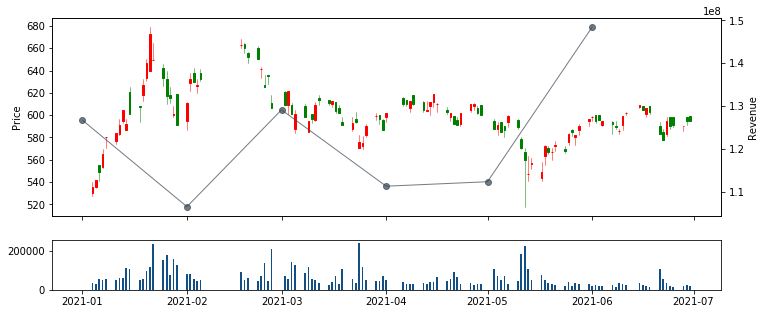

In [13]:
def Main(stock_number, start_month,end_time=datetime.datetime.now().strftime("%Y-%m-%d")):  
    His_Stock = pd.read_csv('His_Stock.csv')
    His_Stock["stock_number"]=His_Stock['stock_number'].astype('str')
    RowData_df_craw_stock,His_Stock = craw_stock(His_Stock,stock_number,start_month,end_time)
    RowData_df_craw_stock.head(10)
    data_final,df_final=DataCleaning(RowData_df_craw_stock)
    RowData_df_craw_revenue,His_Stock=craw_revenue(His_Stock,stock_number,start_month,end_time)
    df_Revenue=RevenueDataCleaning(RowData_df_craw_revenue)
    drew(data_final,df_final,df_Revenue)
    His_Stock=His_Stock.drop_duplicates()
    His_Stock.to_csv('His_Stock.csv',index=False)
    

Main('2330',"2021-01-01","2021-06-01")